## <span style="color:blue">Problem Set 9</span>

<Enter your name here>

### <font color="blue">Overview</font>
In this problem set, you will create an interactive service that provides movie information to the user.  You will make use of a free REST API from the Open Movie Database (described here: http://www.omdbapi.com).  To access the API, you will need an API key (token) that is used to authenticate your requests to the OMDb REST API.
  
#### <font color="blue">Get an OMDb API key</font>
To acquire a key, do the following:
- Navigate to http://www.omdbapi.com/apikey.aspx 
- Click on FREE to acquire a free key.
- Complete the form filling in your email address (use your WCC address), name, and the usage description.
- After completing the form, click Submit.
- An email will be sent to the address entered in the form.  Follow the instructions in the email.
- Once you secure the API key, overwrite the placeholder in the cell below

#### <font color="blue">Run the cell below</font>
By running this cell, all the items in that cell are loaded into the address space making them available for use in later cells.  Do not duplicate any of the code below in later cells.

In [1]:
import os
import requests
import json
from matplotlib import pyplot as plt
from matplotlib import image as mpimg

# Store folder paths in variables so file locations are easy to update
data_dir = "Data"
images_dir = os.path.join(data_dir, "images")

# Store file names in variables, then build the full paths
poster_filename = "poster.jpg"
previously_viewed_filename = "viewed_movies.txt"
poster_path = os.path.join(images_dir, poster_filename)
PREVIOUSLY_VIEWED_FNAME = previously_viewed_filename

# Store the API key in one variable for this assignment
# In normal project work, secrets such as API keys should be stored in a secure place, such as a .env file.
OMDB_API_KEY = "aae6657"

def showImage(movie, file):
    image = mpimg.imread(file)
    plt.title(movie)
    plt.imshow(image)
    plt.show()
    return

print("Setup complete.")
print("Data folder:", data_dir)
print("Images folder:", images_dir)
print("Poster path:", poster_path)
print("Previously viewed file:", PREVIOUSLY_VIEWED_FNAME)

Setup complete.
Data folder: Data
Images folder: Data/images
Poster path: Data/images/poster.jpg
Previously viewed file: viewed_movies.txt


<div style="background-color:#fff4e5; color:#222; padding:12px; border-left:6px solid #f0a020; border-radius:6px;">

### 🛠️ Problem Set 9: Image Paths and API Keys

### poster.jpg should live in a project data folder instead of the same flat folder as the notebook. A cleaner structure is Data/images/poster.jpg.

### Storing data_dir, images_dir, poster_filename, and poster_path as variables makes the notebook easier to maintain. If the image folder or file name changes later, you update one variable instead of searching through the notebook for hard-coded strings.

### The OMDb API key is still shown in this notebook because this is an assignment, but in normal project work an API key should not be hard-coded in a cell. A more secure approach is to store secrets in a .env file or another protected configuration location, then load them into the program when needed.
</div>

### <font color="blue">Problem 1</font>
Define a function _getOMDBData_ that is passed the parameter _title_ and calls the OMDB API to get the data about a movie.  See the expected output below for an example of the data returned. 

The API requires two parameters to retrieve and return movie information:  _"apikey"_, the key acquire from OMDB, and _"t"_, the movie title.  While you have the liberty to code the API call in any fashion, the snippet below is a suggested format where _title_ is the parameter passed to the function and _OMDB_API_KEY_ is the variable containing the acquired API key.

    pars = {'t':title,'apikey':OMDB_API_KEY}
    response = requests.get('http://www.omdbapi.com/', params=pars)

#### Do the following:
The function _getOMDBData_ accepts the parameter _title_ and uses _try/except_ syntax to accomplish the following:
1. Uses the _requests.get_ method with the required parameters to retrieve information associated with the movie described by _title_. 
2.  Stores the data returned as json into the variable _omdbData_.
3.  If the request is unsuccessful (the _Response_ key of the _omdbData_ has a string value equal to "False") return a boolean_False_ to the calling environment.  
4.  Otherwise return the _variable_.
5. If the _try_ fails, return _False_ to the caller. 

There are two types of errors that can result from a REST API call.  First, an http/https error may occur when the service could not be reached for any reason.  There are many reasons that could cause this error including a invalid or malformed url or loss of connection. You must use _try/except_ to trap this error.  In this case, the function must return a boolean _False_.  Feel free to code additional error handling provided that _False_ is returned.   

The second type of error results from the API returning an error condition,e.g., an unknown move title.  This error is indicated by the string _"False"_ value associated with the key _"Response"_.  in this case, the function returns a boolean _False_ to the caller.  

Also, when the request is successful, return all movie information to the caller.  Do not edit the json in any fashion.

You must have only one instance of this function present in the notebook. DO not duplicated it in later cells.

In [2]:
# Function cell: define getOMDBData so it can be called from later cells
def getOMDBData(title):
    # Use try/except to handle any http/https connection errors
    try:
        # Build the parameters and call the OMDB API with the movie title
        pars = {"t": title, "apikey": OMDB_API_KEY}
        response = requests.get("http://www.omdbapi.com/", params=pars)
        # Convert the response to JSON data
        omdbData = response.json()
        # Check whether the API returned an error response for an unknown title
        if omdbData["Response"] == "False":
            return False
        # Return the full movie data if the request was successful
        return omdbData
    except:
        # Return False if the connection or request failed
        return False

print("Function getOMDBData loaded. Call getOMDBData(title) in another cell.")

Function getOMDBData loaded. Call getOMDBData(title) in another cell.


<div style="background-color:#fff4e5; color:#222; padding:12px; border-left:6px solid #f0a020; border-radius:6px;">

### 🛠️ Problem 1: Function Cell and JSON Formatting

### This is a function-only cell. It defines `getOMDBData`, but the function is meant to be called from later test cells. Adding a comment at the top of the cell helps make that purpose clear.

### Function-only cells should still print a short confirmation after the function is defined. That output tells you the cell ran successfully and the function is now available in memory.

### The function now returns the API data without printing the full JSON inside the function. This prevents surprise output when other functions, such as `getBoxOffice`, call `getOMDBData` many times.

### The test cell is the better place to print `json.dumps(movie_data, indent=2)`. That keeps the readable JSON output available while allowing later reporting cells to control their own output order.
</div>

In [3]:
# Run this cell to test the valid movie title case
movie_data = getOMDBData("Black Panther")
print("getOMDBData test summary")
print("Movie title requested: Black Panther")
print("Movie record returned:", movie_data is not False)
print()
print("Movie record:")
print(json.dumps(movie_data, indent=2))

getOMDBData test summary
Movie title requested: Black Panther
Movie record returned: True

Movie record:
{
  "Title": "Black Panther",
  "Year": "2018",
  "Rated": "PG-13",
  "Released": "16 Feb 2018",
  "Runtime": "134 min",
  "Genre": "Action, Adventure, Sci-Fi",
  "Director": "Ryan Coogler",
  "Writer": "Ryan Coogler, Joe Robert Cole, Stan Lee",
  "Actors": "Chadwick Boseman, Michael B. Jordan, Lupita Nyong'o",
  "Plot": "T'Challa, heir to the hidden but advanced kingdom of Wakanda, must step forward to lead his people into a new future and must confront a challenger from his country's past.",
  "Language": "English, Swahili, Nama, Xhosa, Korean",
  "Country": "United States",
  "Awards": "Won 3 Oscars. 125 wins & 289 nominations total",
  "Poster": "https://m.media-amazon.com/images/M/MV5BMTg1MTY2MjYzNV5BMl5BanBnXkFtZTgwMTc4NTMwNDI@._V1_QL75_UX380_CR0,0,380,562_.jpg",
  "Ratings": [
    {
      "Source": "Internet Movie Database",
      "Value": "7.3/10"
    },
    {
      "Source"

The output below is truncated to save space.
<div class="alert alert-warning">
    <font face="verdana" size="2" color="033971"><strong>Expected Output:</strong><br />
{'Actors': "Chadwick Boseman, Michael B. Jordan, Lupita Nyong'o, Danai Gurira",<br />
 'Awards': '14 nominations.',<br />
 'BoxOffice': '$501,105,037',<br />
 'Country': 'USA, South Africa, South Korea, Australia',<br />
 'DVD': '15 May 2018',<br />
 'Director': 'Ryan Coogler',<br />
 'Genre': 'Action, Adventure, Sci-Fi',<br />
 'Language': 'Swahili, Nama, English, Xhosa, Korean',<br />
 ...</div>

In [4]:
# Run this cell to test the invalid movie title case
movie_data = getOMDBData("asdfasdfasdfasdfasdf")
print("getOMDBData test summary")
print("Movie title requested: asdfasdfasdfasdfasdf")
print("Movie record returned:", movie_data is not False)
print("Returned value:", movie_data)

getOMDBData test summary
Movie title requested: asdfasdfasdfasdfasdf
Movie record returned: False
Returned value: False


<div class="alert alert-warning">
    <font face="verdana" size="2" color="033971"><strong>Expected Output:</strong><br />
False</div>

### <font color="blue">Problem 2:</font> 
Define the function _getMoviesData_ that accepts the parameter _movieTitles_, which is a list of movie titles, calls _getOMDBData_ for each title, builds a list of json returned by _getOMDBData_, and returns that list to the calling environment. The function must handle both the case of valid movie data returned, which is appended to the list, and a _False_ return value, which is skipped,i.e., not appended to the list.

This function does the following:
1. Iterate over _movieTitles_.
2. If getOMBDData returns _False_ , do not append information to the _list_.
3. Otherwise append the movie information to the _list_.
4. Return the _list_.

In [5]:
# Function cell: define getMoviesData so it can be called from later cells
def getMoviesData(movieTitles):
    # Initialize an empty list to hold valid movie results
    movies_list = []
    # Iterate over each title and call getOMDBData
    for title in movieTitles:
        data = getOMDBData(title)
        # Append only valid results, not False values
        if data is not False:
            movies_list.append(data)
    return movies_list

print("Function getMoviesData loaded. Call getMoviesData(movieTitles) in another cell.")

Function getMoviesData loaded. Call getMoviesData(movieTitles) in another cell.


<div style="background-color:#fff4e5; color:#222; padding:12px; border-left:6px solid #f0a020; border-radius:6px;">

### 🛠️ Problem 2: Function Cell Commenting

### This cell only defines `getMoviesData`, so it should be labeled as a function cell at the top. That makes it clear the function is loaded here and called from later cells.

### The comments were also updated to avoid first-person wording. Instead of `# I initialize...`, use direct comments such as `# Initialize an empty list to hold valid movie results`.

### The final print statement confirms that the function definition cell ran successfully.
</div>

In [6]:
# Test getMoviesData with a list of valid and invalid movie titles
movie_titles = [
    "Superbabies: Baby Geniuses 2",
    "The Shawshank Redemption",
    "Foobarbat",
    "asdfasdfasdfasdfasdf",
    "Thor"
]

# Store the returned list of movie dictionaries for inspection
movies_data = getMoviesData(movie_titles)

# Print a summary of the records returned by the API calls
print("Movie lookup summary")
print("Titles requested:", len(movie_titles))
print("Movies returned:", len(movies_data))
print("Titles skipped or not found:", len(movie_titles) - len(movies_data))
print()

# Print a quick title/year summary for the returned movies
print("Returned movie title/year summary:")
for movie in movies_data:
    print(movie["Title"], movie["Year"])
print()

# Print the nested movie data in a readable JSON-style format
print("Returned movie records:")
print(json.dumps(movies_data, indent=2))

Movie lookup summary
Titles requested: 5
Movies returned: 3
Titles skipped or not found: 2

Returned movie title/year summary:
Superbabies: Baby Geniuses 2 2004
The Shawshank Redemption 1994
Thor 2011

Returned movie records:
[
  {
    "Title": "Superbabies: Baby Geniuses 2",
    "Year": "2004",
    "Rated": "PG",
    "Released": "27 Aug 2004",
    "Runtime": "88 min",
    "Genre": "Comedy, Family, Sci-Fi",
    "Director": "Bob Clark",
    "Writer": "Robert Grasmere, Francisca Matos, Steven Paul",
    "Actors": "Jon Voight, Scott Baio, Vanessa Angel",
    "Plot": "A group of smart-talking toddlers find themselves at the center of a media mogul's experiment to crack the code to baby talk. The toddlers must race against time for the sake of babies everywhere.",
    "Language": "English",
    "Country": "Germany, United Kingdom, United States, Canada",
    "Awards": "13 nominations",
    "Poster": "https://m.media-amazon.com/images/M/MV5BNjY4NjM3MjQ2OF5BMl5BanBnXkFtZTcwOTc3NzYyMQ@@._V1_SX

<div style="background-color:#fff4e5; color:#222; padding:12px; border-left:6px solid #f0a020; border-radius:6px;">

### 🛠️ Problem 2: Formatting Function Test Output

### This is a good place to use `json.dumps(..., indent=2)` because `getMoviesData` returns a list of movie dictionaries. Without formatting, nested data can be difficult to scan in the notebook output.

### Storing the result in `movies_data` before printing also makes the test easier to debug. You can inspect the returned list, reuse it in later cells, or print selected fields from it if the full JSON-style output becomes too long.

```python
movies_data = getMoviesData(movie_titles)
print(json.dumps(movies_data, indent=2))
```

### This formatting helps you see which valid movies were returned and what keys are available in each movie record.

### The older output printed only selected fields, such as the title and year. That was readable, but it did not make it clear what full data was retrieved from the API or how that data was stored in Python.

### Seeing the full formatted list is valuable for troubleshooting because you can confirm which movie records were returned, which invalid titles were skipped, and what keys are available for later steps.

### The summary lines are also useful because this test list intentionally includes invalid movie titles. Printing requested, returned, and skipped counts makes it clear that the function handled both successful lookups and not-found results.

### Printing a title/year summary before the full JSON-style output gives you a quick human-readable check, while keeping `json.dumps` preserves the detailed structure for debugging.
</div>

<div class="alert alert-warning">
    <font face="verdana" size="2" color="033971"><strong>Expected Output:</strong><br />
Superbabies: Baby Geniuses 2 2004<br/>
The Shawshank Redemption 1994<br/>
Thor 2011</div>

### <font color="blue">Problem 3:</font> 
Define a function _sortedMoviesData_ that accepts a list of movie titles, calls _getMoviesData_ and sorts the json returned in descending order on the _imdbRating_.  The sorted list is returned to the calling environment.

Note: The value associated with the _"imdbRating"_ key is a string which must be converted to a float.  

The optimized solution uses the sorted function and a lambda expression.

In [7]:
# Function cell: define sortedMoviesData so it can be called from later cells
def sortedMoviesData(movieTitles):
    # Retrieve all valid movie dictionaries using getMoviesData
    movies_list = getMoviesData(movieTitles)
    # Sort in descending order by imdbRating, converting the rating string to a float
    return sorted(movies_list, key=lambda x: float(x["imdbRating"]), reverse=True)

print("Function sortedMoviesData loaded. Call sortedMoviesData(movieTitles) in another cell.")

Function sortedMoviesData loaded. Call sortedMoviesData(movieTitles) in another cell.


<div style="background-color:#fff4e5; color:#222; padding:12px; border-left:6px solid #f0a020; border-radius:6px;">

### 🛠️ Problem 3: Function Cell Commenting

### This cell only defines `sortedMoviesData`, so it now has a top comment that identifies it as a function cell. That makes it clear the cell loads a reusable function for later code.

### The comments were updated to remove first-person wording. For example, `# I call getMoviesData...` became `# Retrieve all valid movie dictionaries using getMoviesData`.

### The print statement at the end confirms that the function loaded successfully, even though the function itself will be called in a later test cell.
</div>

Complete the code below that uses the _sortedMoviesData_ function to produce the expected output shown.

In [8]:
# Test sortedMoviesData with a list of valid and invalid movie titles
movie_titles = [
    "Gladiator",
    "The Shawshank Redemption",
    "Clue",
    "asdfasdfasdfasdfasdf",
    "Black Panther",
    "Extraction",
    "Source Code"
]

# Store the sorted movie records returned by sortedMoviesData
result = sortedMoviesData(movie_titles)

# Print a summary of the sorted records
print("Sorted movie lookup summary")
print("Titles requested:", len(movie_titles))
print("Movies returned:", len(result))
print("Titles skipped or not found:", len(movie_titles) - len(result))
print()

# Print the expected table output with title, year, and rating
print("     {0:30} {1:4} {2:4}".format("Movie", "Year", "Rating"))
print("     {0:30} {1:4} {2:4}".format("-----", "----", "------"))
for movie in result:
    print("     {0:30} {1:4}   {2:4}".format(movie["Title"], movie["Year"], movie["imdbRating"]))
print()

# Print the full sorted movie records in a readable JSON-style format
print("Sorted movie records:")
print(json.dumps(result, indent=2))

Sorted movie lookup summary
Titles requested: 7
Movies returned: 6
Titles skipped or not found: 1

     Movie                          Year Rating
     -----                          ---- ------
     The Shawshank Redemption       1994   9.3 
     Gladiator                      2000   8.5 
     Source Code                    2011   7.5 
     Clue                           1985   7.3 
     Black Panther                  2018   7.3 
     Extraction                     2020   6.8 

Sorted movie records:
[
  {
    "Title": "The Shawshank Redemption",
    "Year": "1994",
    "Rated": "R",
    "Released": "14 Oct 1994",
    "Runtime": "142 min",
    "Genre": "Drama",
    "Director": "Frank Darabont",
    "Writer": "Stephen King, Frank Darabont",
    "Actors": "Tim Robbins, Morgan Freeman, Bob Gunton",
    "Plot": "A wrongfully convicted banker forms a close friendship with a hardened convict over a quarter century while retaining his humanity through simple acts of compassion.",
    "Languag

<div style="background-color:#fff4e5; color:#222; padding:12px; border-left:6px solid #f0a020; border-radius:6px;">

### 🛠️ Problem 3: Test Output Summary and Debugging

### This test cell now starts with a summary that shows how many titles were requested, how many movie records were returned, and how many titles were skipped or not found. That is useful because the input list includes an invalid movie title on purpose.

### The formatted table is still useful because it matches the expected assignment output. The full `json.dumps(result, indent=2)` output is added after the table so the complete sorted records can be inspected for troubleshooting.

### This follows the notebook commenting guide: use a quick human-readable summary first, then show the detailed nested data when the function returns multiple records.

### This kind of output is not just for class assignments. In real-world projects, summary counts, readable tables, and detailed structured output are critical for logging activity, testing code, and troubleshooting problems. These insights help you quickly see what happened, what data was returned, and where something may have gone wrong.
</div>

<div class="alert alert-warning">
    <font face="verdana" size="2" color="033971"><strong>Expected Output:</strong><br />
The table below is intended to provide a sense of the appearance of the output and the column alignment.  There is no need to attempt any additional formatting.        
</div>  

### <font color="blue">PROBLEM 4:</font>
The next few problems require the use of a file that tracks the movies that the user has viewed. The name of the file is contained in the variable _PREVIOUSLY_VIEWED_FNAME_ initialized in the first cell. 

Write a function called _loadViewedMovies_ that attempts to open the file.  The first time this code is executed, the file does not exist resulting in a failure to open the file.  Later problems will create and populate the file. In the case of an exception when attempting to open the file, the function will return an empty list.  In the case of a successful read, the function returns the contents of the file after they converted to json.

 The function does the following:
1. Open the file using the name in _PREVIOUSLY_VIEWED_FNAME_.
2. If the file opens successfully:
   1. Read the contents of the file.
   2. Converts the contents to json into the variable _viewed_movies_.
3. Otherwise:
   1. Assign an empty list to _viewed_movies_.
4. Return the variable _viewed_movies_.

Notes:
- Use try/except when opening the file.
- The contents of PREVIOUSLY_VIEWED_FNAME is json list of movie titles
- As you write code for later problems, you may corrupt the file.  In that case, delete the file and rerun this cell.

In [9]:
# Function cell: define loadViewedMovies so it can be called from later cells
def loadViewedMovies():
    # Use try/except in case the viewed movies file does not exist yet
    try:
        f = open(PREVIOUSLY_VIEWED_FNAME, "r")
        contents = f.read()
        f.close()
        # Convert the JSON string back into a list
        viewed_movies = json.loads(contents)
    except:
        # Return an empty list if the file does not exist or cannot be read
        viewed_movies = []
    return viewed_movies

print("Function loadViewedMovies loaded. Call loadViewedMovies() in another cell.")

Function loadViewedMovies loaded. Call loadViewedMovies() in another cell.


<div style="background-color:#fff4e5; color:#222; padding:12px; border-left:6px solid #f0a020; border-radius:6px;">

### 🛠️ Problem 4: Function Cell and File Loading

### This cell only defines `loadViewedMovies`, so it now has a top function-cell comment and a confirmation message after the function definition.

### The comments were updated to remove first-person wording. Instead of `# I use try/except...`, use direct wording such as `# Use try/except in case the viewed movies file does not exist yet`.

### The function itself returns the viewed movies list when the file can be read. On the first run, the file may not exist yet, so returning an empty list is expected. The next test cell should print the returned list so the output confirms how many records were loaded and what values were read.
</div>

In [10]:
# Test loadViewedMovies and confirm what was loaded from the viewed movies file
viewed_movies = loadViewedMovies()

print("Viewed movies load summary")
print("File loaded:", PREVIOUSLY_VIEWED_FNAME)
print("Movies loaded:", len(viewed_movies))
print()

print("Viewed movies:")
print(json.dumps(viewed_movies, indent=2))

Viewed movies load summary
File loaded: viewed_movies.txt
Movies loaded: 7

Viewed movies:
[
  "It's a Beautiful Life",
  "Black Panther",
  "Thor",
  "Greyhound",
  "The Matrix Reloaded",
  "Godfather",
  "Happy Gilmore"
]


<div style="background-color:#fff4e5; color:#222; padding:12px; border-left:6px solid #f0a020; border-radius:6px;">

### 🛠️ Problem 4: File Load Test Output

### This test cell now prints a load summary before printing the list. That makes the output more useful for troubleshooting because it confirms which file was read and how many movie titles were loaded.

### `json.dumps(viewed_movies, indent=2)` is useful here because `viewed_movies` is a list. If the file is empty or does not exist yet, the count should be `0` and the printed list should be `[]`.
</div>

The first time the above cell is run, an empty list should display.  If the file identified by _PREVIOUSLY_VIEWED_FNAME_ is not empty, it's contents will display.
<div class="alert alert-warning">
    <font face="verdana" size="2" color="033971"><strong>Expected Output:</strong><br />
[]<br />
</span>

### <font color="blue">PROBLEM 5:</font>
Define a function *markAsViewed* that accepts a movie title, checks if the title is present in the list _viewed_movies_. If the title is present in the list, do nothing.  Otherwise, add the title to _viewed_movies_ and writes the _viewed_movies_ to the file.

Do the following:
1. If that title IS in viewed_movies, do nothing.
2. If that title IS NOT in viewed_movies.
    - Add the title to the list viewed_movies.
    - Open the file
    - Write the entire contents of viewed_movies to the file PREVIOUSLY_VIEWED_FNAME as a json-formatted string.
    - Close the file.
3. return nothing.


In [11]:
# Function cell: define markAsViewed so it can be called from later cells
def markAsViewed(title):
    # Use global to modify the viewed_movies list inside this function
    global viewed_movies
    # Add the title only if it is not already in the list
    if title not in viewed_movies:
        viewed_movies.append(title)
        # Write the updated list back to the file as JSON
        f = open(PREVIOUSLY_VIEWED_FNAME, "w")
        f.write(json.dumps(viewed_movies, indent=2))
        f.close()

print("Function markAsViewed loaded. Call markAsViewed(title) in another cell.")

Function markAsViewed loaded. Call markAsViewed(title) in another cell.


<div style="background-color:#fff4e5; color:#222; padding:12px; border-left:6px solid #f0a020; border-radius:6px;">

### 🛠️ Problem 5: Function Cell and JSON File Writing

### This cell only defines `markAsViewed`, so it now has a top function-cell comment and a confirmation message after the function definition.

### The comments were updated to remove first-person wording. For example, `# I write...` became `# Write the updated list back to the file as JSON`.

### Because this function writes a list to a file, `json.dumps(viewed_movies, indent=2)` keeps the saved file readable. The test cell that calls this function should confirm how many records were written and show the updated list so the file-writing behavior is easy to troubleshoot.
</div>

In [12]:
# Test markAsViewed by adding several movie titles
movies_to_mark = [
    "It's a Beautiful Life",
    "Black Panther",
    "Thor"
]

for movie in movies_to_mark:
    markAsViewed(movie)

# Reload the viewed movies list to confirm that the file was written correctly
viewed_movies = loadViewedMovies()

print("Viewed movies write summary")
print("Movies requested to mark as viewed:", len(movies_to_mark))
print("Movies currently stored:", len(viewed_movies))
print("File updated:", PREVIOUSLY_VIEWED_FNAME)
print()

print("Viewed movie titles:")
for movie in viewed_movies:
    print(movie)
print()

print("Viewed movies records:")
print(json.dumps(viewed_movies, indent=2))

Viewed movies write summary
Movies requested to mark as viewed: 3
Movies currently stored: 7
File updated: viewed_movies.txt

Viewed movie titles:
It's a Beautiful Life
Black Panther
Thor
Greyhound
The Matrix Reloaded
Godfather
Happy Gilmore

Viewed movies records:
[
  "It's a Beautiful Life",
  "Black Panther",
  "Thor",
  "Greyhound",
  "The Matrix Reloaded",
  "Godfather",
  "Happy Gilmore"
]


<div style="background-color:#fff4e5; color:#222; padding:12px; border-left:6px solid #f0a020; border-radius:6px;">

### 🛠️ Problem 5: File Write Test Output

### This test cell now confirms the write operation with summary counts, the file name, a readable list of viewed titles, and the full JSON-style list.

### That output is useful for real-world troubleshooting because it confirms that `markAsViewed` updated the in-memory list and that `loadViewedMovies` can read the saved file back successfully.

### The comment style was also updated to describe the action directly instead of using first-person wording.
</div>

If the file viewed_movies.txt file was empty before you ran this cell, the expected output is shown below.<br />
<div class="alert alert-warning">
    <font face="verdana" size="2" color="033971"><strong>Expected Output:</strong><br />
["It's a Beautiful Life", 'Black Panther', 'Thor']</div>

### <font color="blue">PROBLEM 6:</font>
Define a function *getMovieAdvice* that does the following:

1. Ask the user for a list of movie titles separated by commas
2. Convert the user input to a list of titles.
2. Call the _sortedMoviesData_ function (defined earlier) on that list of titles.
3. Iterate over the list returned by _sortedMoviesData_.
   1. If the user has already watched the movie, print "You have already watched {title}"
   2. Otherwise print the title, year, rating, and plot in the format:

          {title} ({year}): {rating}
          --------------------
          {plot}

   3. Ask the user if they want to watch the movie (yes or no)
      1. If the user types "no" (or anything other than yes) do nothing.
      2. Otherwise call markAsViewed and print the runtime in the format:
          Watched {title} for {runtime}
4. return nothing

In [13]:
# Function cell: define getMovieAdvice so it can be called from later cells
def getMovieAdvice():
    # Ask for movie titles as a comma-separated list and show an example format
    user_input = input("Enter movie titles separated by commas, for example: Thor, Clue: ")
    # Split the input into individual titles and remove extra spaces
    titles = [t.strip() for t in user_input.split(",")]
    # Retrieve valid movie records sorted by rating
    results = sortedMoviesData(titles)

    print("Movie advice summary")
    print("Titles entered:", len(titles))
    print("Movie records found:", len(results))
    print("Titles skipped or not found:", len(titles) - len(results))

    for movie in results:
        title = movie["Title"]
        # Check whether the selected movie is already in the viewed list
        if title in viewed_movies:
            print("\nAlready viewed:", title)
        else:
            # Print the selected movie title, year, rating, and plot
            print("\nRecommendation: {}".format(title))
            print("{} ({}) - Rating: {}".format(title, movie["Year"], movie["imdbRating"]))
            print("----------------------------")
            print(movie["Plot"])
            print()
            answer = input("Want to watch {}? (yes or no): ".format(title))
            if answer.lower() == "yes":
                # Mark the selected movie as viewed and print the runtime
                markAsViewed(title)
                print("Marked as viewed:", title)
                print("Runtime:", movie["Runtime"])

print("Function getMovieAdvice loaded. Call getMovieAdvice() in another cell.")

Function getMovieAdvice loaded. Call getMovieAdvice() in another cell.


<div style="background-color:#fff4e5; color:#222; padding:12px; border-left:6px solid #f0a020; border-radius:6px;">

### 🛠️ Problem 6: Interactive Prompt Workflow

### This function is interactive, so the prompt and output need to guide the user through the workflow clearly. The input prompt now includes an example: `Thor, Clue`.

### The summary output shows how many titles were entered, how many movie records were found, and how many titles were skipped or not found. This is practical logging for testing and troubleshooting because it confirms what happened after the user entered data.

### The follow-up prompt now names the selected movie, such as `Want to watch Thor?`, instead of using a generic message. When multiple movies are returned, naming the current record makes the workflow much easier to follow.

### The output also names the selected movie when it is already viewed or marked as viewed, so it is clear which record was selected, displayed, and stored.
</div>

In [14]:
# Run this cell to test the function getMovieAdvice
getMovieAdvice()

Movie advice summary
Titles entered: 2
Movie records found: 1
Titles skipped or not found: 1

Recommendation: Ex-E.T.
Ex-E.T. (2008) - Rating: 6.4
----------------------------
A little child in a far-away planet ruled by synchronism and conformity starts showing antisocial behavior to the embarrassment of his parents, who take him to the doctors to be fixed.

Marked as viewed: Ex-E.T.
Runtime: 8 min


<div class="alert alert-warning">
    <font face="verdana" size="2" color="033971"><strong>Expected Output:</strong><br />
Enter some movies separated by commas: Thor,Greyhound<br />
<br />
You have already seen Thor<br />
<br />
Greyhound (2020): 7.0<br />
----------------------------<br />
Several months after the U.S. entry into World War II, an inexperienced U.S. Navy commander must lead an Allied convoy being stalked by a German submarine wolf pack.<br />
<br />
        Want to watch this movie? (yes or no):</div>

### <font color="blue">PROBLEM 7:</font>
One of the elements in the json returned by the OMDB API is a link to the movie poster image.  This link is found in the element identifed by the key _"Poster"_.  Use this link to retrieve the image and display it using the function _showImage_ which was defined in the first cell.

Do the following:
1. Iterate over the _movies_ list defined below.
2. Call getOMDBData using the movie title and store the result into a _variable_.
3. Using the _variable_, retrieve the value associated with the key "Poster" and store it in the variable _link_.
4. Print _link_.
5. Call _requests.get_ using _link_ to retrieve the image into the variable _poster_.  Use try/except to handle an http/https errors. You have the freedom to handle http/https errors in any fashion. 
6. Open a file called _poster.jpg_ using the mode "wb" (write binary).
7. The image for the poster is in the response (from requests) attribute content. Write content to the file.
8. close the file.
9. call _showImage_ passing the movie title and the file name _poster.jpg_.

Poster download summary
Movies requested: 4
Poster output folder: Data/images

Checking poster for: The Shawshank Redemption
Poster link for The Shawshank Redemption: https://m.media-amazon.com/images/M/MV5BMDAyY2FhYjctNDc5OS00MDNlLThiMGUtY2UxYWVkNGY2ZjljXkEyXkFqcGc@._V1_QL75_UX380_CR0,4,380,562_.jpg
Poster file name: the_shawshank_redemption_1994_r.jpg
Poster path: Data/images/the_shawshank_redemption_1994_r.jpg
Saved poster for The Shawshank Redemption to Data/images/the_shawshank_redemption_1994_r.jpg


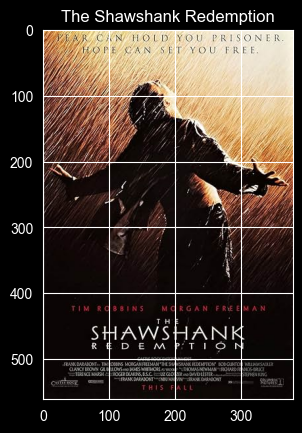


Checking poster for: Gladiator
Poster link for Gladiator: https://m.media-amazon.com/images/M/MV5BYWQ4YmNjYjEtOWE1Zi00Y2U4LWI4NTAtMTU0MjkxNWQ1ZmJiXkEyXkFqcGc@._V1_QL75_UX380_CR0,0,380,562_.jpg
Poster file name: gladiator_2000_r.jpg
Poster path: Data/images/gladiator_2000_r.jpg
Saved poster for Gladiator to Data/images/gladiator_2000_r.jpg


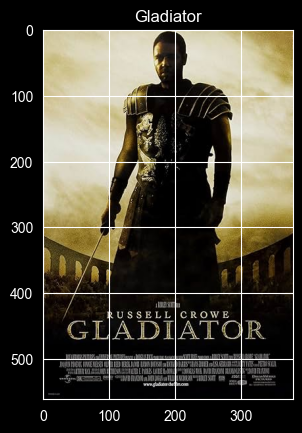


Checking poster for: asdfasdfasdfasdfasdf
Skipped movie, no OMDB record found: asdfasdfasdfasdfasdf

Checking poster for: Source Code
Poster link for Source Code: https://m.media-amazon.com/images/M/MV5BMTY0MTc3MzMzNV5BMl5BanBnXkFtZTcwNDE4MjE0NA@@._V1_SX300.jpg
Poster file name: source_code_2011_pg-13.jpg
Poster path: Data/images/source_code_2011_pg-13.jpg
Saved poster for Source Code to Data/images/source_code_2011_pg-13.jpg


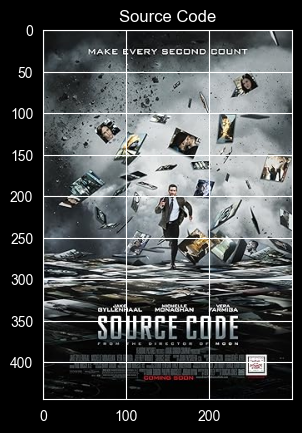


Poster download complete.
Posters downloaded: 3
Movies skipped or not found: 1
Poster downloads failed: 0


In [15]:
movies = ["The Shawshank Redemption", "Gladiator", "asdfasdfasdfasdfasdf", "Source Code"]

print("Poster download summary")
print("Movies requested:", len(movies))
print("Poster output folder:", images_dir)
print()

posters_downloaded = 0
movies_skipped = 0
posters_failed = 0

# Iterate over each movie and display its poster
for movie in movies:
    print("Checking poster for:", movie)
    data = getOMDBData(movie)
    # Skip movies that were not found in OMDB
    if data is False:
        movies_skipped = movies_skipped + 1
        print("Skipped movie, no OMDB record found:", movie)
        print()
        continue

    # Get poster details from the selected movie data
    link = data["Poster"]
    title = data["Title"]
    year = data["Year"]
    rated = data["Rated"]

    # Build a unique poster file name from title, year, and content rating
    clean_title = title.lower().replace(" ", "_")
    poster_filename = "{}_{}_{}.jpg".format(clean_title, year, rated.lower())
    poster_path = os.path.join(images_dir, poster_filename)

    print("Poster link for {}: {}".format(title, link))
    print("Poster file name:", poster_filename)
    print("Poster path:", poster_path)
    try:
        # Download the poster image using the poster link
        poster = requests.get(link)
        # Write the image content to the unique poster path as a binary file
        f = open(poster_path, "wb")
        f.write(poster.content)
        f.close()
        posters_downloaded = posters_downloaded + 1
        print("Saved poster for {} to {}".format(title, poster_path))
        showImage(title, poster_path)
    except:
        posters_failed = posters_failed + 1
        print("Could not retrieve poster for", title)
    print()

print("Poster download complete.")
print("Posters downloaded:", posters_downloaded)
print("Movies skipped or not found:", movies_skipped)
print("Poster downloads failed:", posters_failed)

<div style="background-color:#fff4e5; color:#222; padding:12px; border-left:6px solid #f0a020; border-radius:6px;">

### 🛠️ Problem 7: Unique Poster File Names

### The earlier version wrote every image to the same `poster_path`, so each successful poster download overwrote the previous poster file. This version builds a new file name for each movie inside the loop.

### The file name is built from values in the structured OMDB JSON response: movie title, year, and content rating. For example, `The Shawshank Redemption`, `1994`, and `R` becomes `the_shawshank_redemption_1994_r.jpg`.

### Naming files from meaningful data values gives the file context. A name like `poster.jpg` does not explain what the image contains, but `the_shawshank_redemption_1994_r.jpg` tells the reader which movie the image belongs to without opening the file.

### This matters for accessibility, organization, and troubleshooting. Descriptive file names make files easier to scan, easier to reference in code, and easier to debug when an image is missing, overwritten, or connected to the wrong record.

### The code still uses the shared `images_dir` path from the setup cell, then combines the generated file name with `os.path.join(images_dir, poster_filename)`. This keeps the folder location centralized while allowing each poster to have its own output file.

### The output now prints the movie title, poster link, generated file name, and full poster path. Those details are useful logging because they confirm exactly which structured JSON record created each image file.
</div>

For the sake of simplicity, the image is not shown in the expected output below.  However, if you coded the problem correctly, the link and the image associated with the link will appear,
<div class="alert alert-warning">
    <font face="verdana" size="2" color="033971"><strong>Expected Output:</strong><br />
https://m.media-amazon.com/images/M/MV5BMTY0MTc3MzMzNV5BMl5BanBnXkFtZTcwNDE4MjE0NA@@._V1_SX300.jpg<br />
        <span style="font-style: italic">An image should display here.</span>
        </div>        

### <font color="blue">PROBLEM 8:</font>
Another element in the json returned by the OMDB API is total revenue that the movie generated.  The element key is called "BoxOffice".  

This problem is composed of two parts.  The first part is to write a function called _getBoxOffice_ that is passed a movie title, calls _getOMDBData_ and handles three possible cases of the return value:
1. The return value is False because the title could not be found.  In this case, return -1.
2. The return value contains valid movie information and the value associated with the key _"BoxOffice"_ can be successfully converted to an integer, return that integer.
3. The return value contains valid movie information and the value associated with the key _"BoxOffice"_ cannot be successfully converted to an integer, return 0.  Note, _try/except_ is helpful in this case.

The second part is to write code that iterates over the titles in the list _movies_ below, calls _GetBoxOffice_ for each movie title, displays the title and revenue, and uses and accumulation pattern to total of the revenue. Print as shown in expected output.  For the case where the function returns -1, print "invalid", when 0 is returned print "N/A"

In [16]:
# Function cell: define getBoxOffice so it can be called from later cells
def getBoxOffice(title):
    # Retrieve the movie information from OMDB
    data = getOMDBData(title)
    # Return -1 when the movie title was not found
    if data is False:
        return -1
    try:
        # Remove dollar signs and commas before converting BoxOffice to an integer
        revenue = int(data["BoxOffice"].replace(",", "").replace("$", ""))
        return revenue
    except:
        # Return 0 when the BoxOffice value cannot be converted to an integer
        return 0

print("Function getBoxOffice loaded. Call getBoxOffice(title) in another cell.")

Function getBoxOffice loaded. Call getBoxOffice(title) in another cell.


In [17]:
movies = ["The Batman", "The Northman", "abcx", "Death on the Nile", "Queen of the Nile"]

box_office_results = []
total = 0
valid_count = 0
invalid_count = 0
unavailable_count = 0

# Call getBoxOffice for each movie title and store the display result
for title in movies:
    revenue = getBoxOffice(title)
    if revenue == -1:
        invalid_count = invalid_count + 1
        display_revenue = "invalid"
    elif revenue == 0:
        unavailable_count = unavailable_count + 1
        display_revenue = "N/A"
    else:
        valid_count = valid_count + 1
        total = total + revenue
        display_revenue = "{:,}".format(revenue)
    box_office_results.append({"title": title, "revenue": revenue, "display_revenue": display_revenue})

print("Box office lookup summary")
print("Movies requested:", len(movies))
print("Movies with valid revenue:", valid_count)
print("Movies not found:", invalid_count)
print("Movies with unavailable revenue:", unavailable_count)
print()

print("Box office result records:")
print(json.dumps(box_office_results, indent=2))
print()

print("{0:<25} {1:>15}".format("Movie", "Revenue"))
print("{0:<25} {1:>15}".format("-----", "-------"))
for result in box_office_results:
    print("{0:<25} {1:>15}".format(result["title"], result["display_revenue"]))
print("{0:<25} {1:>15,}".format("Total revenue:", total))

Box office lookup summary
Movies requested: 5
Movies with valid revenue: 3
Movies not found: 1
Movies with unavailable revenue: 1

Box office result records:
[
  {
    "title": "The Batman",
    "revenue": 369801546,
    "display_revenue": "369,801,546"
  },
  {
    "title": "The Northman",
    "revenue": 34233110,
    "display_revenue": "34,233,110"
  },
  {
    "title": "abcx",
    "revenue": -1,
    "display_revenue": "invalid"
  },
  {
    "title": "Death on the Nile",
    "revenue": 45630104,
    "display_revenue": "45,630,104"
  },
  {
    "title": "Queen of the Nile",
    "revenue": 0,
    "display_revenue": "N/A"
  }
]

Movie                             Revenue
-----                             -------
The Batman                    369,801,546
The Northman                   34,233,110
abcx                              invalid
Death on the Nile              45,630,104
Queen of the Nile                     N/A
Total revenue:                449,664,760


<div style="background-color:#fff4e5; color:#222; padding:12px; border-left:6px solid #f0a020; border-radius:6px;">

### 🛠️ Problem 8: Separate Function Logic from Formatted Output

### The `getBoxOffice` function is now in its own cell. That makes the function easier to test because the cell only defines reusable logic and confirms that the function loaded.

### The movie list and formatted output are in the next cell. This keeps the reporting workflow separate from the function definition, which is a cleaner pattern when a function will be reused later.

### The output cell now stores each lookup result in `box_office_results` before printing. The summary appears first, then `json.dumps(box_office_results, indent=2)` shows the structured records that were created.

### Printing the JSON-style records before the final table is helpful for troubleshooting because it shows the raw stored values and the display values together. Then the formatted table gives the reader a clean report.

### The summary lines are practical logging. They show how many movie titles were requested, how many returned valid revenue, how many were not found, and how many had unavailable revenue.
</div>

<div class="alert alert-warning">
    <font face="verdana" size="2" color="033971"><strong>Expected Output:</strong><br />
The exact revenue values may change if the OMDB data changes, but the output should include summary counts, JSON-style result records, and a formatted table.
        </div>

### <font color="blue">PROBLEM 9:</font>
One of the features of the OMDB API is the ability to search for movies using a keyword.  The API searches a number of elements for the keyword and returns json, which, when converted, is a dictionary composed of one element with a key of _"Search"_.  The value associated with that key is a list of dictionaries where each dictionary contains information for a movie.  The content of that dictionary is similar, but not identical, to that returned by _getOMDBData_.

This problem is composed of two parts.  First, write a function called _searchOMDBData_ that is passed the parameter _word_.  The function is almost identical to getOMDBData.  The only difference is replacing the API parameter _'t'_ with the parameter _'s'_.  The value associated with _'s'_ is the content of _word_.

The second part does the following:
1. Calls _searchOMDBData_ with the parameter _keyword_ below. 
2. Print the headers for the table as shown below.
3. Iterate over the list associated with the key "Search" in the content returned by the function.
4. Prints the year and title in a formatted table fashion as shown in expected output.

In [18]:
# Function cell: define searchOMDBData so it can be called from later cells
def searchOMDBData(word):
    # Use try/except to handle any connection errors
    try:
        # Use the s parameter to search by keyword instead of exact title
        pars = {"s": word, "apikey": OMDB_API_KEY}
        response = requests.get("http://www.omdbapi.com/", params=pars)
        omdbData = response.json()
        # Return False when OMDB does not find matching search results
        if omdbData["Response"] == "False":
            return False
        return omdbData
    except:
        return False

print("Function searchOMDBData loaded. Call searchOMDBData(word) in another cell.")

Function searchOMDBData loaded. Call searchOMDBData(word) in another cell.


In [19]:
keyword = "Nile"

# Call searchOMDBData and store the structured search response
results = searchOMDBData(keyword)

if results is False:
    print("OMDB search summary")
    print("Keyword searched:", keyword)
    print("Movies returned: 0")
    print("Search failed or no matching records found.")
else:
    search_results = results["Search"]

    print("OMDB search summary")
    print("Keyword searched:", keyword)
    print("Movies returned:", len(search_results))
    print()

    print("OMDB search result records:")
    print(json.dumps(search_results, indent=2))
    print()

    print("{0:<8}{1}".format("Year", "Title"))
    print("{0:<8}{1}".format("----", "-----"))
    for movie in search_results:
        print("{0:<8}{1}".format(movie["Year"], movie["Title"]))

OMDB search summary
Keyword searched: Nile
Movies returned: 10

OMDB search result records:
[
  {
    "Title": "Death on the Nile",
    "Year": "2022",
    "imdbID": "tt7657566",
    "Type": "movie",
    "Poster": "https://m.media-amazon.com/images/M/MV5BYjBkMTRkMmUtNGQ5Ni00YjkwLThhMmMtZjI1M2U2NzRhNjkwXkEyXkFqcGc@._V1_SX300.jpg"
  },
  {
    "Title": "The Jewel of the Nile",
    "Year": "1985",
    "imdbID": "tt0089370",
    "Type": "movie",
    "Poster": "https://m.media-amazon.com/images/M/MV5BNmNlMjE0NDAtYmE4MS00OTEzLTljYjYtODM4MjUwNjM1N2RhXkEyXkFqcGc@._V1_SX300.jpg"
  },
  {
    "Title": "Death on the Nile",
    "Year": "1978",
    "imdbID": "tt0077413",
    "Type": "movie",
    "Poster": "https://m.media-amazon.com/images/M/MV5BYTkzMWViYWMtMWMwNS00MzgwLTgyZTUtNjVkOTE2YjE0MmM5XkEyXkFqcGc@._V1_SX300.jpg"
  },
  {
    "Title": "The Nile Hilton Incident",
    "Year": "2017",
    "imdbID": "tt5540188",
    "Type": "movie",
    "Poster": "https://m.media-amazon.com/images/M/MV5BZjM5YTIw

<div style="background-color:#fff4e5; color:#222; padding:12px; border-left:6px solid #f0a020; border-radius:6px;">

### 🛠️ Problem 9: Function Cell and Search Result Output

### The `searchOMDBData` function is now in its own cell. This keeps the reusable API-search logic separate from the cell that chooses a keyword and formats the output.

### The calling cell now starts with a summary showing the keyword searched and the number of movie records returned. This gives immediate confirmation that the API search worked.

### The JSON-style output from `json.dumps(search_results, indent=2)` shows the structured list returned by OMDB. This is helpful because the search response has a `Search` list, and each item contains fields such as title, year, IMDb id, type, and poster.

### The formatted table still appears after the JSON records so the reader gets both views: the complete structure for troubleshooting and a clean year/title report for the assignment output.
</div>

<div class="alert alert-warning">
    <font face="verdana" size="2" color="033971"><strong>Expected Output:</strong><br />
The exact OMDB search results may change, but the output should include summary counts, JSON-style search records, and a formatted year/title table.
        </div>

### <font color="blue">Problem 10</font>
Use the functions _searchOMDBData_ and _getBoxOffice_ to produce the output shown in expected output.

In [20]:
keyword = "Lord"

# Search for movies using the keyword
results = searchOMDBData(keyword)

lord_movie_results = []
valid_count = 0
invalid_count = 0
unavailable_count = 0

if results is False:
    print("Lord movie revenue summary")
    print("Keyword searched:", keyword)
    print("Movies returned: 0")
    print("Search failed or no matching records found.")
else:
    search_results = results["Search"]

    # Look up box office revenue for each movie returned by the search
    for movie in search_results:
        revenue = getBoxOffice(movie["Title"])
        if revenue == -1:
            invalid_count = invalid_count + 1
            display_revenue = "invalid"
        elif revenue == 0:
            unavailable_count = unavailable_count + 1
            display_revenue = "N/A"
        else:
            valid_count = valid_count + 1
            display_revenue = "{:,}".format(revenue)

        lord_movie_results.append({
            "year": movie["Year"],
            "title": movie["Title"],
            "revenue": revenue,
            "display_revenue": display_revenue
        })

    print("Lord movie revenue summary")
    print("Keyword searched:", keyword)
    print("Movies returned:", len(search_results))
    print("Movies with valid revenue:", valid_count)
    print("Movies not found:", invalid_count)
    print("Movies with unavailable revenue:", unavailable_count)
    print()

    print("Lord movie revenue records:")
    print(json.dumps(lord_movie_results, indent=2))
    print()

    print("{0:<8} {1:<45} {2:>12}".format("Year", "Title", "Revenue"))
    print("{0:<8} {1:<45} {2:>12}".format("----", "-----", "-------"))
    for movie in lord_movie_results:
        print("{0:<8} {1:<45} {2:>12}".format(movie["year"], movie["title"], movie["display_revenue"]))

Lord movie revenue summary
Keyword searched: Lord
Movies returned: 10
Movies with valid revenue: 9
Movies not found: 0
Movies with unavailable revenue: 1

Lord movie revenue records:
[
  {
    "year": "2001",
    "title": "The Lord of the Rings: The Fellowship of the Ring",
    "revenue": 325873309,
    "display_revenue": "325,873,309"
  },
  {
    "year": "2003",
    "title": "The Lord of the Rings: The Return of the King",
    "revenue": 386975644,
    "display_revenue": "386,975,644"
  },
  {
    "year": "2002",
    "title": "The Lord of the Rings: The Two Towers",
    "revenue": 350104956,
    "display_revenue": "350,104,956"
  },
  {
    "year": "2022\u2013",
    "title": "The Lord of the Rings: The Rings of Power",
    "revenue": 0,
    "display_revenue": "N/A"
  },
  {
    "year": "2005",
    "title": "Lord of War",
    "revenue": 24149632,
    "display_revenue": "24,149,632"
  },
  {
    "year": "1978",
    "title": "The Lord of the Rings",
    "revenue": 30471420,
    "display

<div style="background-color:#fff4e5; color:#222; padding:12px; border-left:6px solid #f0a020; border-radius:6px;">

### 🛠️ Problem 10: Combine Search Results with Box Office Data

### This cell uses two earlier functions together: `searchOMDBData(keyword)` gets the search results, and `getBoxOffice(title)` retrieves revenue for each returned title.

### The code now stores each combined result in `lord_movie_results` before printing. Each record keeps the year, title, raw revenue value, and display revenue value together, which makes the data easier to inspect and reuse.

### The output starts with summary counts, then prints `json.dumps(lord_movie_results, indent=2)`, and then prints the formatted table. This follows the same practical logging pattern used earlier: quick summary, structured data for troubleshooting, then a readable report.

### The comments were also updated to remove first-person wording and focus on what the code is doing.
</div>

<div class="alert alert-warning">
    <font face="verdana" size="2" color="033971"><strong>Expected Output:</strong><br />
The exact OMDB results and revenue values may change, but the output should include summary counts, JSON-style records, and a formatted table.
        </div>